# Customer Churn Analysis

## Python Data Analysis Project

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("customer_churn_data_raw.xlsx")

In [3]:
df.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [4]:
df.shape

(21, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     str           
 1   name        21 non-null     str           
 2   country     18 non-null     str           
 3   state       21 non-null     str           
 4   gender      21 non-null     str           
 5   dob         21 non-null     datetime64[us]
 6   interests   4 non-null      str           
 7   pincode     0 non-null      float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 1.4 KB


In [6]:
df.isnull().sum()

customerid     0
name           0
country        3
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64

In [7]:
# Check rows that contain at least one missing value
df[df.isnull().any(axis=1)]

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10,NaN,NaN
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21,NaN,NaN
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29,NaN,NaN


In [8]:
# Check which rows have missing values in the country column
df[df["country"].isnull()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07,NaN,NaN
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01,NaN,NaN


In [9]:
# Fill missing country values based on the corresponding state
df.loc[5, "country"] = "India"
df.loc[8, "country"] = "Nepal"
df.loc[12, "country"] = "India"

# Check the country column to verify the changes
df["country"]

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: str

In [10]:
# Replace missing values in the interests column
# We do not guess the customer's interest, so we mark it as Not Specified
df["interests"] = df["interests"].fillna("Not Specified")

# Check the interests column after cleaning
df["interests"]

0            travel
1     Not Specified
2             movie
3     Not Specified
4             drama
5     Not Specified
6     Not Specified
7     Not Specified
8     Not Specified
9     Not Specified
10    Not Specified
11    Not Specified
12    Not Specified
13    Not Specified
14    Not Specified
15              job
16    Not Specified
17    Not Specified
18    Not Specified
19    Not Specified
20    Not Specified
Name: interests, dtype: str

In [11]:
# Drop the pincode column because all its values are missing
df = df.drop(columns=["pincode"])

# Check the remaining columns
df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests'], dtype='str')

In [12]:
# Final check for missing values after data cleaning
df.isnull().sum()

customerid    0
name          0
country       0
state         0
gender        0
dob           0
interests     0
dtype: int64

## Basic statistics

In [13]:
# Get basic statistical information about the dataset
df.describe(include="all")

,customerid,name,country,state,gender,dob,interests
count,21,21,21,21,21,21,21
unique,21,21,2,9,4,NaN,5
top,0002-ORFBO,keshav,India,Delhi,Female,NaN,Not Specified
freq,1,1,19,4,9,NaN,17
mean,NaN,NaN,NaN,NaN,NaN,1989-08-26 12:34:17.142857,NaN
min,NaN,NaN,NaN,NaN,NaN,1976-09-21 00:00:00,NaN
25%,NaN,NaN,NaN,NaN,NaN,1982-04-12 00:00:00,NaN
50%,NaN,NaN,NaN,NaN,NaN,1990-05-05 00:00:00,NaN
75%,NaN,NaN,NaN,NaN,NaN,1995-11-23 00:00:00,NaN
max,NaN,NaN,NaN,NaN,NaN,2004-12-01 00:00:00,NaN


In [14]:
# Count the number of customers from each country
country_counts = df["country"].value_counts()

# Display the customer count by country
country_counts

country
India    19
Nepal     2
Name: count, dtype: int64

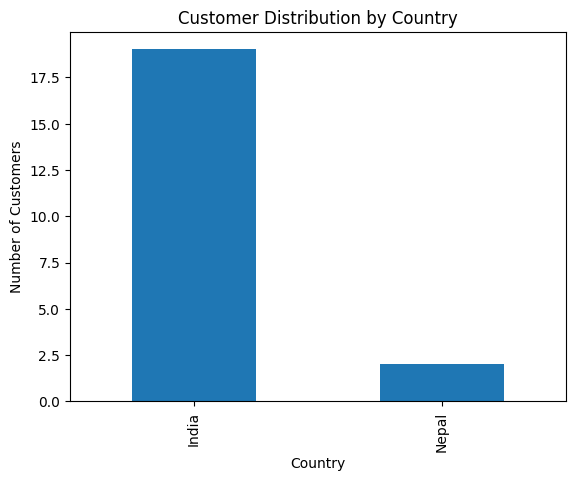

In [15]:
# Create a bar chart to visualize customer distribution by country
country_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

***India has the highest number of customers (19), while Nepal has only 2 customers in the dataset.***

In [16]:
# Count the number of customers in each state
state_counts = df["state"].value_counts()

# Display the customer count by state
state_counts

state
Delhi            4
Maharashtra      3
Meghalaya        3
Karnataka        2
Rajasthan        2
Kathmandu        2
Telangana        2
Uttar Pradesh    2
Nagaland         1
Name: count, dtype: int64

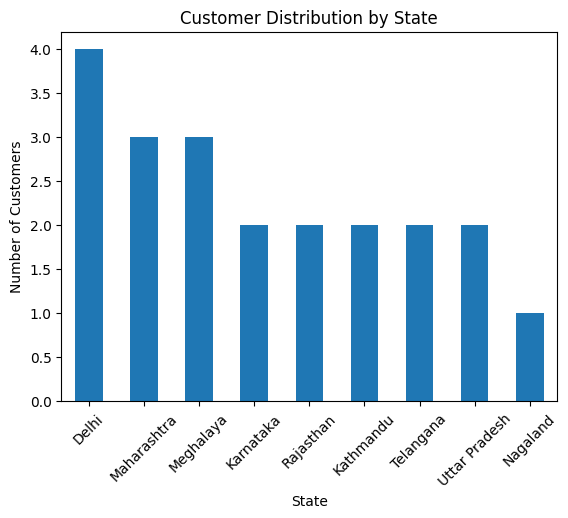

In [17]:
# Create a bar chart to visualize customer distribution by state
state_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

# Rotate state names for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [18]:
# Count the number of customers for each gender
gender_counts = df["gender"].value_counts()

# Display the customer count by gender
gender_counts

gender
Female    9
Male      6
Women     3
Men       3
Name: count, dtype: int64

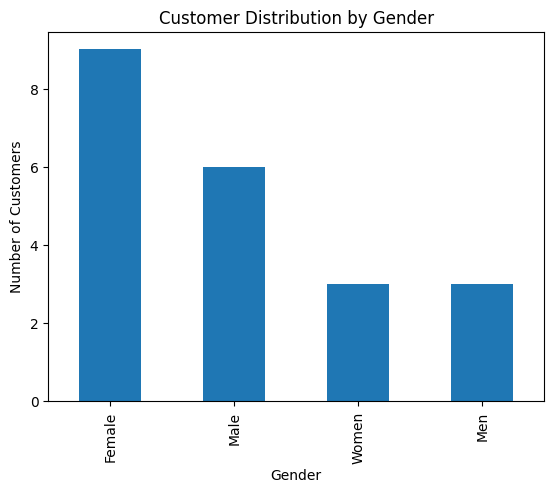

In [19]:
# Create a bar chart to visualize customer distribution by gender
gender_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [20]:
# Convert the DOB column into datetime format
df["dob"] = pd.to_datetime(df["dob"])

# Calculate customer age using the current year
current_year = pd.Timestamp.now().year
df["age"] = current_year - df["dob"].dt.year

# Display customer names, date of birth, and calculated age
df[["name", "dob", "age"]]

,name,dob,age
0,keshav,1982-04-12,44
1,raghav,1995-11-23,31
2,lalita,1978-02-15,48
3,mohan,2001-08-30,25
4,mira,1990-05-05,36
5,durga,1988-12-10,38
6,mina,1976-09-21,50
7,madan,1999-03-14,27
8,maya,1985-07-07,41
9,arjun,1993-10-29,33


In [21]:
# Create age groups for customers
bins = [0, 18, 30, 40, 50, 100]
labels = ["Below 18", "18-30", "31-40", "41-50", "Above 50"]

# Assign each customer to an age group
df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

# Count customers in each age group
age_group_counts = df["age_group"].value_counts().sort_index()

# Display the customer count by age group
age_group_counts

age_group
Below 18    0
18-30       5
31-40       8
41-50       8
Above 50    0
Name: count, dtype: int64

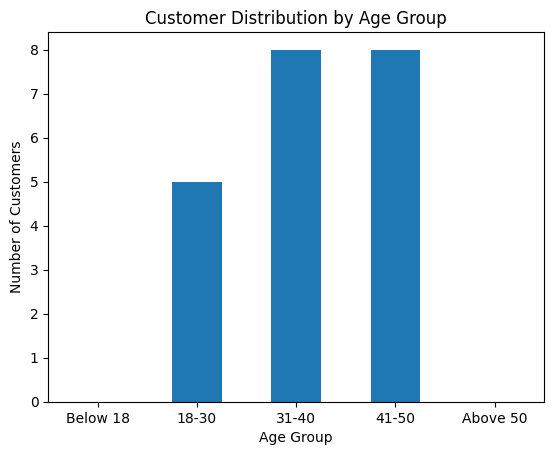

In [22]:
# Create a bar chart to visualize customers by age group
age_group_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Keep age group labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [23]:
# Count customers for each interest
interest_counts = df["interests"].value_counts()

# Display the interest-wise customer count
interest_counts

interests
Not Specified    17
travel            1
movie             1
drama             1
job               1
Name: count, dtype: int64

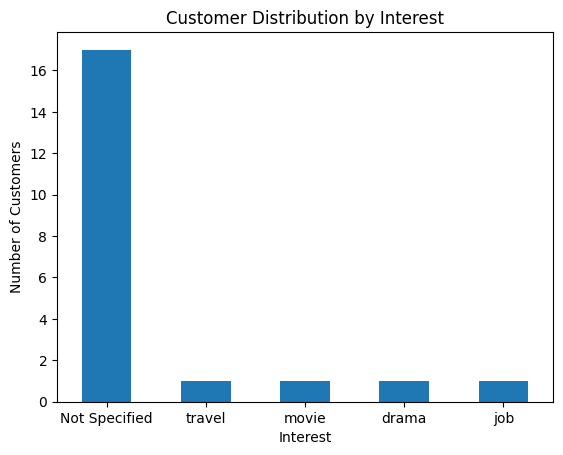

In [24]:
# Create a bar chart to visualize customer interests
interest_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by Interest")
plt.xlabel("Interest")
plt.ylabel("Number of Customers")

# Keep interest labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [25]:
# Standardize gender values
# Combine "Men" with "Male" and "Women" with "Female"
df["gender"] = df["gender"].replace({
    "Men": "Male",
    "Women": "Female"
})

# Count customers after standardizing gender
gender_counts = df["gender"].value_counts()

# Display the cleaned gender counts
gender_counts

gender
Female    12
Male       9
Name: count, dtype: int64

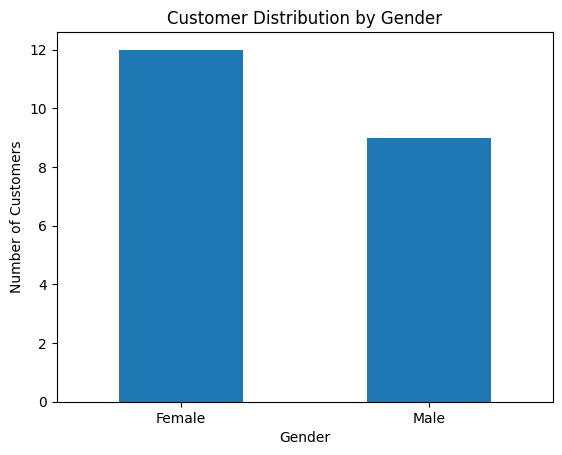

In [26]:
# Create a bar chart for the cleaned gender data
gender_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Keep gender labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [27]:
# Count customers from each state
state_counts = df["state"].value_counts()

# Display state-wise customer count
state_counts

state
Delhi            4
Maharashtra      3
Meghalaya        3
Karnataka        2
Rajasthan        2
Kathmandu        2
Telangana        2
Uttar Pradesh    2
Nagaland         1
Name: count, dtype: int64

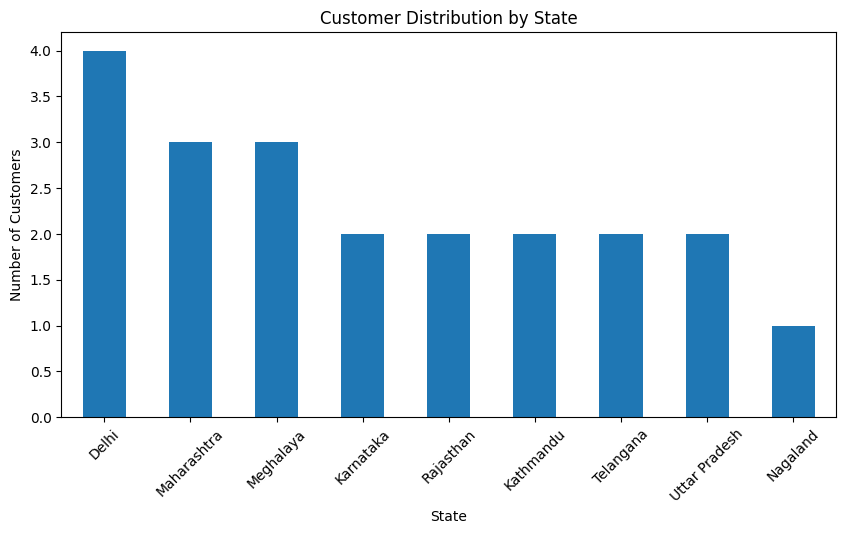

In [28]:
# Create a bar chart for customer distribution by state
state_counts.plot(kind="bar", figsize=(10, 5))

# Add chart title
plt.title("Customer Distribution by State")

# Add labels to the axes
plt.xlabel("State")
plt.ylabel("Number of Customers")

# Keep state names readable
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [29]:
# Check for duplicate customer records
duplicate_count = df.duplicated().sum()

# Display the number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [30]:
# Check unique values in categorical columns
# This helps us identify different categories present in the dataset

print("Country values:")
print(df["country"].unique())

print("\nState values:")
print(df["state"].unique())

print("\nGender values:")
print(df["gender"].unique())

print("\nInterest values:")
print(df["interests"].unique())

Country values:
<StringArray>
['India', 'Nepal']
Length: 2, dtype: str

State values:
<StringArray>
[  'Maharashtra',     'Karnataka',         'Delhi',      'Nagaland',
     'Meghalaya',     'Rajasthan',     'Kathmandu',     'Telangana',
 'Uttar Pradesh']
Length: 9, dtype: str

Gender values:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Interest values:
<StringArray>
['travel', 'Not Specified', 'movie', 'drama', 'job']
Length: 5, dtype: str


In [31]:
# Analyze the age distribution of customers
# This helps us understand which age groups have more customers

print("Age Statistics:")
print(df["age"].describe())

# Find the average age of customers
print("\nAverage Age:")
print(df["age"].mean())

# Find the youngest customer
print("\nMinimum Age:")
print(df["age"].min())

# Find the oldest customer
print("\nMaximum Age:")
print(df["age"].max())

Age Statistics:
count    21.000000
mean     36.904762
std       8.525871
min      22.000000
25%      31.000000
50%      36.000000
75%      44.000000
max      50.000000
Name: age, dtype: float64

Average Age:
36.904761904761905

Minimum Age:
22

Maximum Age:
50


In [32]:
# Count the number of customers in each age group
# This helps us understand the distribution of customers by age

age_group_counts = df["age_group"].value_counts().sort_index()

# Display the customer count for each age group
print(age_group_counts)

age_group
Below 18    0
18-30       5
31-40       8
41-50       8
Above 50    0
Name: count, dtype: int64


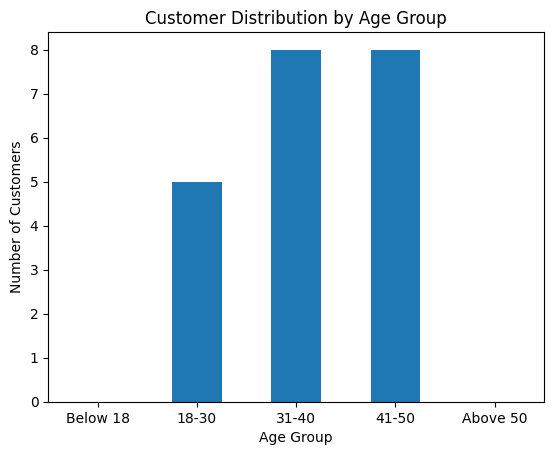

In [33]:
# Create a bar chart to visualize customer distribution by age group

age_group_counts.plot(kind="bar")

# Add title and axis labels
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Keep age group labels straight
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [34]:
# Compare customers by age group and gender
# This helps us understand the gender distribution within each age group

age_gender = pd.crosstab(df["age_group"], df["gender"])

# Display the result
print(age_gender)

gender     Female  Male
age_group              
18-30           2     3
31-40           5     3
41-50           5     3


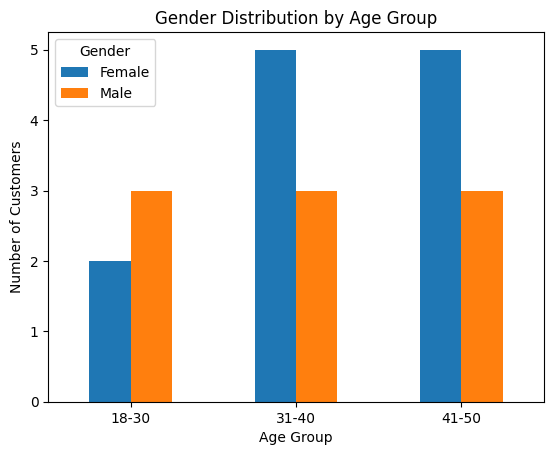

In [35]:
# Create a bar chart to compare male and female customers
# across different age groups

age_gender.plot(kind="bar")

# Add title and axis labels
plt.title("Gender Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Keep age group labels straight
plt.xticks(rotation=0)

# Add legend to identify Male and Female
plt.legend(title="Gender")

# Display the chart
plt.show()

In [36]:
# Compare customers by state and gender
# This helps us understand the gender distribution in each state

state_gender = pd.crosstab(df["state"], df["gender"])

# Display the result
print(state_gender)

gender         Female  Male
state                      
Delhi               4     0
Karnataka           1     1
Kathmandu           1     1
Maharashtra         1     2
Meghalaya           3     0
Nagaland            0     1
Rajasthan           1     1
Telangana           1     1
Uttar Pradesh       0     2


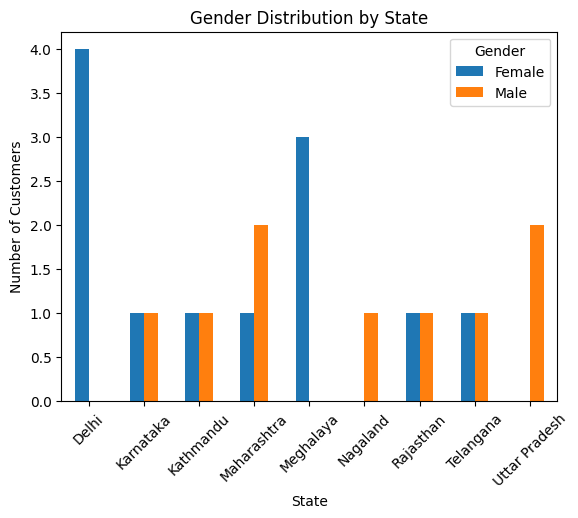

In [37]:
# Create a bar chart to compare male and female customers
# across different states

state_gender.plot(kind="bar")

# Add title and axis labels
plt.title("Gender Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

# Rotate state names for better readability
plt.xticks(rotation=45)

# Add legend to identify Male and Female
plt.legend(title="Gender")

# Display the chart
plt.show()

In [38]:
# Compare customers by interest and gender
# This helps us understand which interests are more common
# among male and female customers

interest_gender = pd.crosstab(df["interests"], df["gender"])

# Display the result
print(interest_gender)

gender         Female  Male
interests                  
Not Specified       9     8
drama               1     0
job                 1     0
movie               1     0
travel              0     1


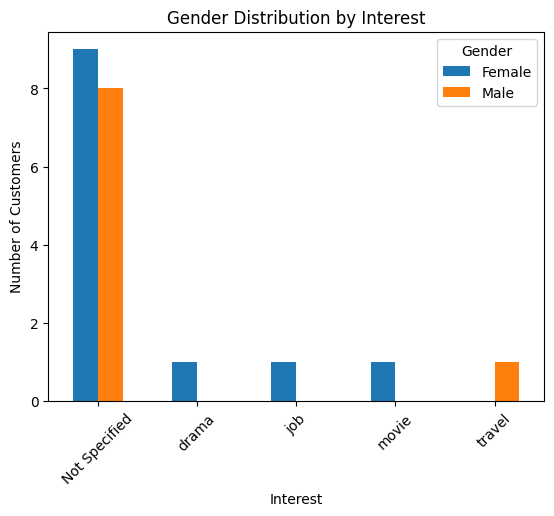

In [39]:
# Create a bar chart to compare male and female customers
# across different interests

interest_gender.plot(kind="bar")

# Add title and axis labels
plt.title("Gender Distribution by Interest")
plt.xlabel("Interest")
plt.ylabel("Number of Customers")

# Rotate interest names for better readability
plt.xticks(rotation=45)

# Add legend to identify Male and Female
plt.legend(title="Gender")

# Display the chart
plt.show()

In [40]:
# Compare customers by age group and interest
# This helps us understand which interests are common
# in different age groups

age_interest = pd.crosstab(df["age_group"], df["interests"])

# Display the result
print(age_interest)

interests  Not Specified  drama  job  movie  travel
age_group                                          
18-30                  5      0    0      0       0
31-40                  6      1    1      0       0
41-50                  6      0    0      1       1


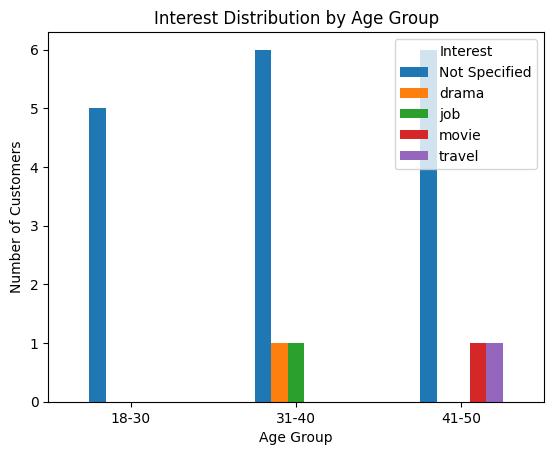

In [41]:
# Create a bar chart to compare interests across different age groups
# This helps us understand which interests are common in each age group

age_interest.plot(kind="bar")

# Add title and axis labels
plt.title("Interest Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Rotate age group labels for better readability
plt.xticks(rotation=0)

# Add legend to identify different interests
plt.legend(title="Interest")

# Display the chart
plt.show()

In [42]:
# Check the distribution of customers by country and age group
# This helps us understand the age profile of customers
# in each country

country_age = pd.crosstab(df["country"], df["age_group"])

# Display the result
print(country_age)

age_group  18-30  31-40  41-50
country                       
India          5      7      7
Nepal          0      1      1


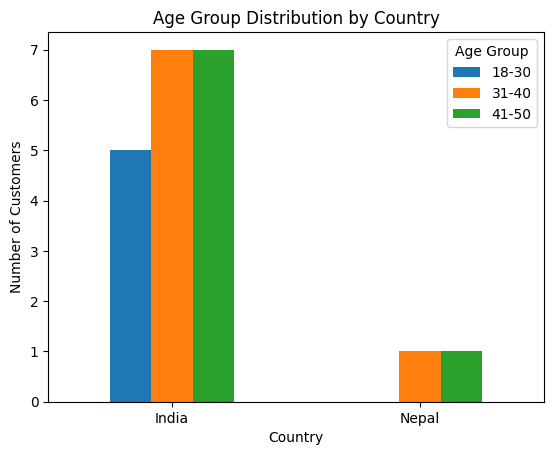

In [43]:
# Create a bar chart to compare age groups across countries
# This helps us understand the age distribution of customers
# in each country

country_age.plot(kind="bar")

# Add title and axis labels
plt.title("Age Group Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Keep country names horizontal for better readability
plt.xticks(rotation=0)

# Add legend to identify different age groups
plt.legend(title="Age Group")

# Display the chart
plt.show()

In [44]:
# Compare customers by country and gender
# This helps us understand the gender distribution
# in each country

country_gender = pd.crosstab(df["country"], df["gender"])

# Display the result
print(country_gender)

gender   Female  Male
country              
India        11     8
Nepal         1     1


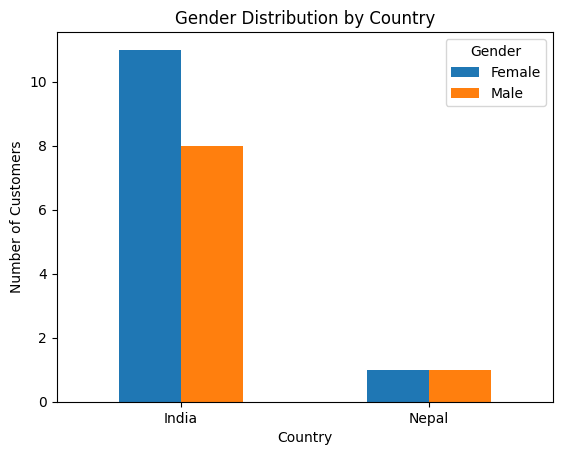

In [45]:
# Create a bar chart to compare gender distribution across countries
# This helps us understand how many male and female customers
# are present in each country

country_gender.plot(kind="bar")

# Add title and axis labels
plt.title("Gender Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Keep country names horizontal for better readability
plt.xticks(rotation=0)

# Add legend to identify genders
plt.legend(title="Gender")

# Display the chart
plt.show()

In [46]:
# Calculate the average age of customers for each gender
# This helps us compare the average age of female and male customers

avg_age_gender = df.groupby("gender")["age"].mean()

# Display the average age for each gender
print(avg_age_gender)

gender
Female    38.416667
Male      34.888889
Name: age, dtype: float64


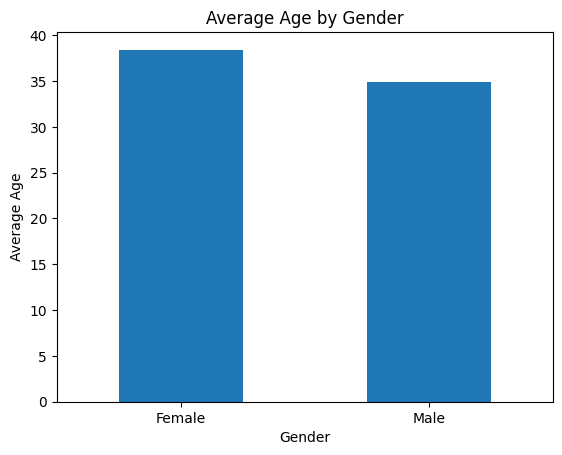

In [47]:
# Create a bar chart to compare average age by gender
# This helps us visually compare the average age of
# female and male customers

avg_age_gender.plot(kind="bar")

# Add title and axis labels
plt.title("Average Age by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Age")

# Keep gender names horizontal for better readability
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [48]:
# Calculate the average age of customers for each state
# This helps us compare the average customer age across different states

avg_age_state = df.groupby("state")["age"].mean()

# Display the average age for each state
print(avg_age_state)

state
Delhi            40.500000
Karnataka        38.000000
Kathmandu        37.000000
Maharashtra      40.666667
Meghalaya        38.666667
Nagaland         25.000000
Rajasthan        26.500000
Telangana        32.500000
Uttar Pradesh    41.000000
Name: age, dtype: float64


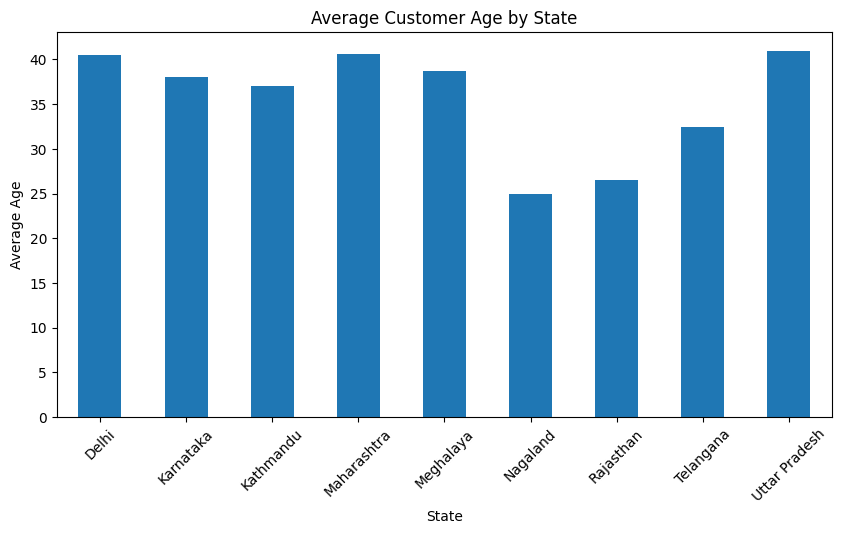

In [49]:
# Create a bar chart to visualize average customer age by state

avg_age_state.plot(kind="bar", figsize=(10, 5))

# Add a title to the chart
plt.title("Average Customer Age by State")

# Label the X-axis
plt.xlabel("State")

# Label the Y-axis
plt.ylabel("Average Age")

# Rotate state names for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [50]:
# Calculate the average age of customers for each country
avg_age_country = df.groupby("country")["age"].mean()

# Display the average age by country
avg_age_country

country
India    36.894737
Nepal    37.000000
Name: age, dtype: float64

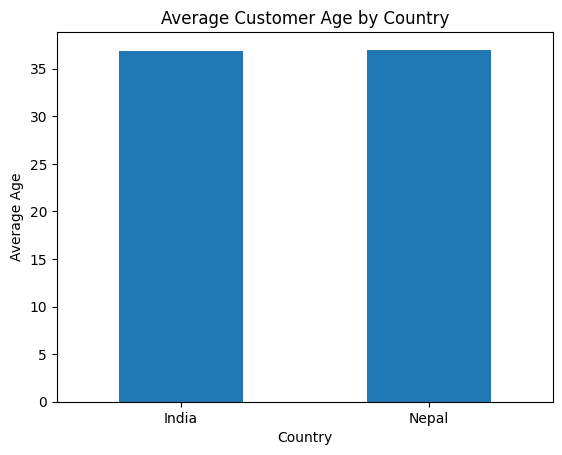

In [51]:
# Create a bar chart to compare average customer age by country
avg_age_country.plot(kind="bar")

# Add chart title
plt.title("Average Customer Age by Country")

# Add axis labels
plt.xlabel("Country")
plt.ylabel("Average Age")

# Keep country names horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [52]:
# Get the top 5 states with the highest number of customers
top_5_states = state_counts.head(5)

# Display the top 5 states
print(top_5_states)

state
Delhi          4
Maharashtra    3
Meghalaya      3
Karnataka      2
Rajasthan      2
Name: count, dtype: int64


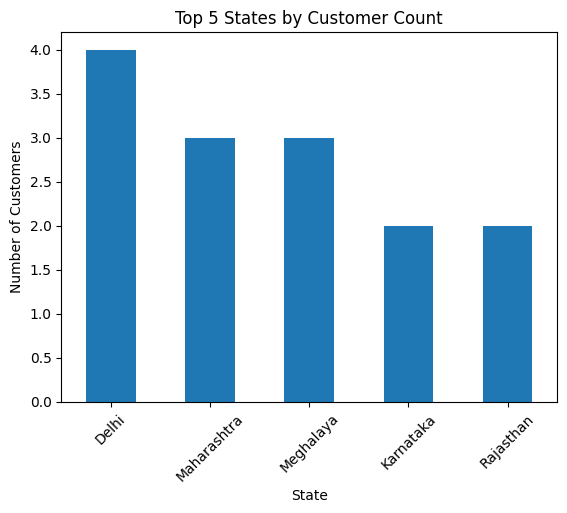

In [53]:
# Create a bar chart for the top 5 states by customer count
top_5_states.plot(kind="bar")

# Add chart title and axis labels
plt.title("Top 5 States by Customer Count")
plt.xlabel("State")
plt.ylabel("Number of Customers")

# Keep state names readable
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [54]:
# Display the final columns in our cleaned dataset
df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'age', 'age_group'],
      dtype='str')

In [55]:
# Display the first 5 rows of the final cleaned dataset
df.head()

,customerid,name,country,state,gender,dob,interests,age,age_group
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,44,41-50
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,Not Specified,31,31-40
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,48,41-50
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,Not Specified,25,18-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,36,31-40


## 📊 Key Insights

1. The dataset contains 21 customers, with 19 from India and 2 from Nepal.

2. There are 12 female customers and 9 male customers.

3. The average customer age is 36.9 years, with ages ranging from 22 to 50 years.

4. The 31–40 and 41–50 age groups are the largest customer segments, with 8 customers each.

5. Delhi has the highest number of customers, with 4 customers.

6. Female customers are more numerous in the 31–40 and 41–50 age groups.

7. Female customers have an average age of 38.42 years, compared with 34.89 years for male customers.

8. 17 out of 21 customers have their interest listed as "Not Specified".

9. The dataset contains no duplicate rows.

## 💡 Conclusion

The analysis shows that the customer base is primarily concentrated in India, with a slightly higher proportion of female customers. Most customers are between 31 and 50 years old. Delhi has the highest customer representation among the listed locations. However, interest information is largely unavailable, so collecting more complete interest data could improve future customer segmentation and marketing analysis.